# Project 1 — Random Forest Regressor
## Crop Yield Prediction

Predicting crop yield (tons/hectare) from rainfall, average temperature, fertilizer amount, and soil quality score.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 800
rainfall = np.random.gamma(4, 40, n)
temperature = np.random.normal(24, 5, n)
fertilizer = np.random.gamma(2, 30, n)
soil_quality = np.random.uniform(1, 10, n)

yield_ = (0.02*rainfall + 0.15*temperature + 0.03*fertilizer + 0.6*soil_quality
          - 0.002*(temperature-24)**2 + np.random.normal(0, 1, n)).clip(0.5, None)

df = pd.DataFrame({'rainfall': rainfall, 'temperature': temperature, 'fertilizer': fertilizer,
                    'soil_quality': soil_quality, 'yield': yield_})
df.head()


,rainfall,temperature,fertilizer,soil_quality,yield
0,188.096556,27.594767,18.667298,8.857388,12.694664
1,136.329276,27.035656,33.915361,2.519726,9.419068
2,129.452988,30.555794,61.020508,1.482713,8.822060
3,129.454145,17.737055,183.377623,7.457185,14.354308
4,303.924405,21.487688,41.029979,5.279281,13.263887


## 2. Preprocessing

In [3]:
X = df.drop('yield', axis=1)
y = df['yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train Model

In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=10,
                               oob_score=True, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("OOB R2:", model.oob_score_)


OOB R2: 0.7562529288102713


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.994484390039456
RMSE: 1.2802385441473059
R2 Score: 0.7714224908937278


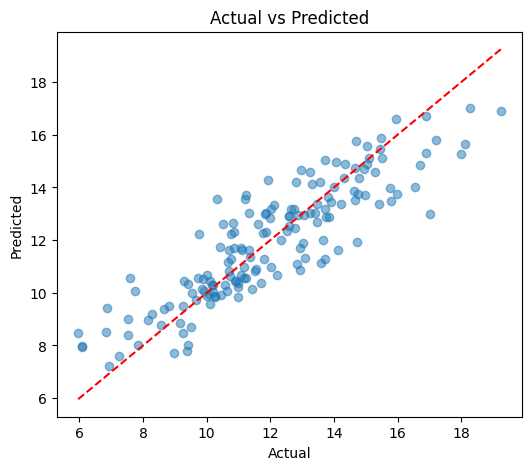

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- The temperature feature has a non-linear (inverted-U) effect on yield — check `model.feature_importances_` and a partial-dependence-style plot to see if the forest captured this curve.
- Compare against a plain Linear Regression on the same data — RF should win clearly due to the non-linear temperature effect.
- Next steps: tune `n_estimators` and `max_depth` with `GridSearchCV`.

